In [2]:
# ============================================================
# CELL 1: Verify X3D loads locally
# ============================================================

import torch

print("Testing X3D-S load locally...")
model_test = torch.hub.load('facebookresearch/pytorchvideo', 'x3d_s', pretrained=False)
print("X3D-S architecture loaded successfully (no pretrained weights needed, we'll load our own checkpoint).")
print("Total params:", sum(p.numel() for p in model_test.parameters()) / 1e6, "M")

Testing X3D-S load locally...
Downloading: "https://github.com/facebookresearch/pytorchvideo/zipball/main" to C:\Users\Surface/.cache\torch\hub\main.zip
X3D-S architecture loaded successfully (no pretrained weights needed, we'll load our own checkpoint).
Total params: 3.794274 M


In [3]:
# ============================================================
# CELL 2: Imports & Load Trained Checkpoint
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("cpu")  # local machine, no GPU
print("Using device:", device)

def build_x3d_model():
    model = torch.hub.load('facebookresearch/pytorchvideo', 'x3d_s', pretrained=False)
    in_features = model.blocks[-1].proj.in_features
    model.blocks[-1].proj = nn.Linear(in_features, 1)
    return model

x3d_model = build_x3d_model()

checkpoint_path = r"D:\Projects\EchoAI-X\models\best_x3d_model.pth"
x3d_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
x3d_model.to(device)
x3d_model.eval()

print("Checkpoint loaded successfully.")

Using device: cpu


Using cache found in C:\Users\Surface/.cache\torch\hub\facebookresearch_pytorchvideo_main


Checkpoint loaded successfully.


In [4]:
# ============================================================
# CELL 3: Data paths (local) + preprocessing helper (same as Kaggle X3D)
# ============================================================

csv_path = r"D:\Projects\EchoAI-X\data\raw\EchoNet-Dynamic\FileList.csv"
frames_dir = r"D:\Projects\EchoAI-X\data\processed\frames"
volumetracings_path = r"D:\Projects\EchoAI-X\data\raw\EchoNet-Dynamic\VolumeTracings.csv"

print("CSV exists:", os.path.exists(csv_path))
print("Frames dir exists:", os.path.exists(frames_dir))
print("VolumeTracings exists:", os.path.exists(volumetracings_path))

file_list = pd.read_csv(csv_path)
test_files = file_list[file_list["Split"] == "TEST"].reset_index(drop=True)
print("Test set size:", len(test_files))

CSV exists: True
Frames dir exists: True
VolumeTracings exists: True
Test set size: 1277


In [5]:
# ============================================================
# CELL 4: X3D preprocessing function (32 -> 13 frames, resize, normalize)
# ============================================================

X3D_NUM_FRAMES = 13
X3D_SIZE = 160
KINETICS_MEAN = np.array([0.45, 0.45, 0.45], dtype=np.float32)
KINETICS_STD = np.array([0.225, 0.225, 0.225], dtype=np.float32)

def load_video_for_x3d(file_name):
    npy_path = os.path.join(frames_dir, file_name + ".npy")
    frames = np.load(npy_path)  # (32, 112, 112, 3), uint8

    indices = np.linspace(0, frames.shape[0] - 1, X3D_NUM_FRAMES).astype(int)
    sampled_indices = indices  # keep for reference (maps back to original 32-frame indexing)
    frames = frames[indices]

    resized = np.array([cv2.resize(f, (X3D_SIZE, X3D_SIZE), interpolation=cv2.INTER_AREA) for f in frames])
    resized = resized.astype(np.float32) / 255.0
    resized = (resized - KINETICS_MEAN) / KINETICS_STD
    resized = np.transpose(resized, (3, 0, 1, 2))  # (C, T, H, W)

    tensor = torch.tensor(resized, dtype=torch.float32).unsqueeze(0)  # (1, C, T, H, W)
    return tensor, sampled_indices

In [6]:
# ============================================================
# CELL 5: Quick sanity test on one sample video
# ============================================================

sample_row = test_files.iloc[0]
sample_file = sample_row["FileName"]
actual_ef = sample_row["EF"]

input_tensor, sampled_indices = load_video_for_x3d(sample_file)

with torch.no_grad():
    pred = x3d_model(input_tensor)

print(f"Video: {sample_file}")
print(f"Actual EF: {actual_ef:.2f}")
print(f"Predicted EF: {pred.item():.2f}")
print(f"Sampled frame indices (out of 32): {sampled_indices}")

Video: 0X100CF05D141FF143
Actual EF: 55.95
Predicted EF: 54.71
Sampled frame indices (out of 32): [ 0  2  5  7 10 12 15 18 20 23 25 28 31]


In [7]:
# ============================================================
# CELL 6: Grad-CAM Implementation for X3D-S
# ============================================================

class GradCAM3D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        self.model.eval()
        self.model.zero_grad()

        output = self.model(input_tensor)  # scalar EF prediction

        # Backward pass on the predicted EF value
        output.backward()

        # activations shape: (1, C, T', H', W')
        # gradients shape:   (1, C, T', H', W')
        weights = self.gradients.mean(dim=(2, 3, 4), keepdim=True)  # Global avg pool over T,H,W -> (1, C, 1, 1, 1)

        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, T', H', W')
        cam = torch.relu(cam)

        cam = cam.squeeze().numpy()  # (T', H', W')

        # Normalize 0-1
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, output.item()


# Identify the target layer: last residual stage before the head
# X3D structure: blocks[0]=stem, blocks[1-4]=res stages, blocks[5]=head
target_layer = x3d_model.blocks[4]

gradcam = GradCAM3D(x3d_model, target_layer)
print("Grad-CAM initialized. Target layer:", target_layer.__class__.__name__)

Grad-CAM initialized. Target layer: ResStage


In [8]:
# ============================================================
# CELL 7: Generate Grad-CAM for the sample video
# ============================================================

input_tensor, sampled_indices = load_video_for_x3d(sample_file)
input_tensor.requires_grad_(True)

cam, pred_value = gradcam.generate(input_tensor)

print("CAM shape (T', H', W'):", cam.shape)
print(f"Predicted EF: {pred_value:.2f} | Actual EF: {actual_ef:.2f}")

CAM shape (T', H', W'): (13, 5, 5)
Predicted EF: 54.71 | Actual EF: 55.95


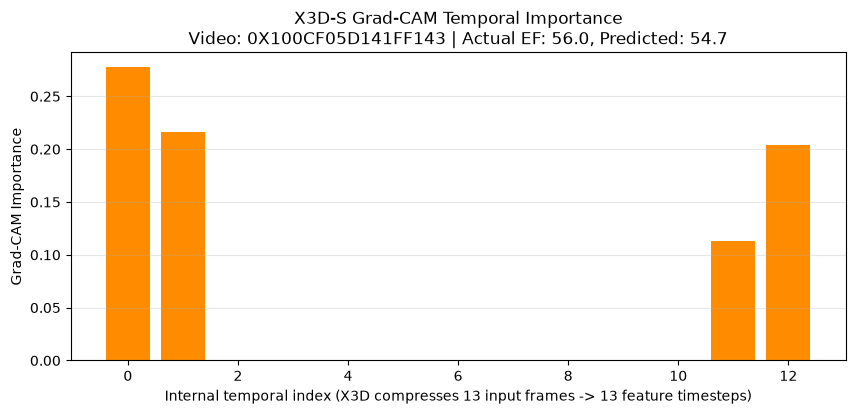

Most important internal timestep: 0


In [9]:
# ============================================================
# CELL 8: Temporal Importance Curve (from Grad-CAM)
# ============================================================
# Har temporal-slice ka overall importance = spatial CAM ka average

temporal_importance = cam.mean(axis=(1, 2))  # (T',) — one score per X3D internal timestep

plt.figure(figsize=(10, 4))
plt.bar(range(len(temporal_importance)), temporal_importance, color="darkorange")
plt.xlabel(f"Internal temporal index (X3D compresses 13 input frames -> {len(temporal_importance)} feature timesteps)")
plt.ylabel("Grad-CAM Importance")
plt.title(f"X3D-S Grad-CAM Temporal Importance\nVideo: {sample_file} | Actual EF: {actual_ef:.1f}, Predicted: {pred_value:.1f}")
plt.grid(alpha=0.3, axis='y')
plt.savefig(r"D:\Projects\EchoAI-X\reports\x3d_novel_model\gradcam_temporal_sample.png", dpi=150)
plt.show()

print("Most important internal timestep:", np.argmax(temporal_importance))

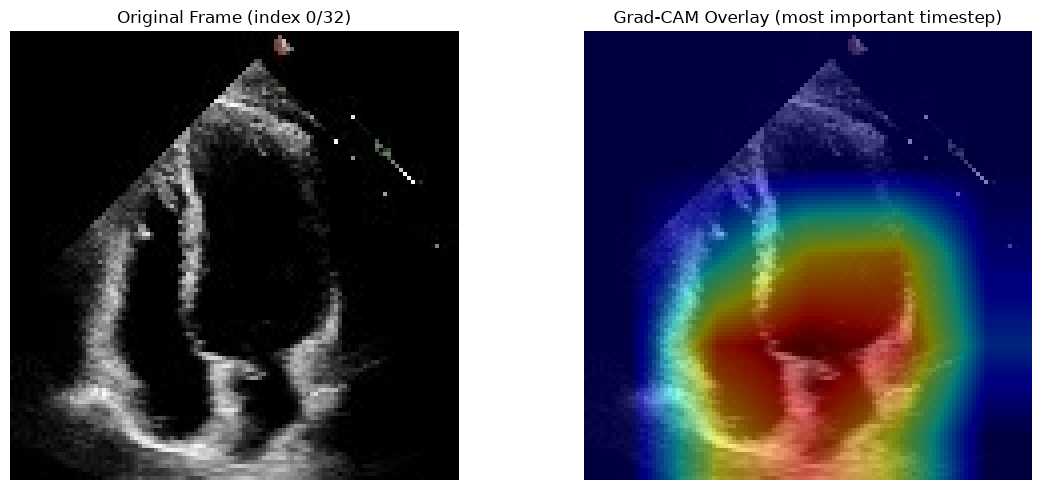

In [10]:
# ============================================================
# CELL 9: Spatial Overlay — Grad-CAM heatmap on original frame
# ============================================================

# Load original (unnormalized) frames for visualization
raw_frames = np.load(os.path.join(frames_dir, sample_file + ".npy"))  # (32, 112, 112, 3), uint8
display_indices = sampled_indices  # the 13 frames X3D actually saw

# Pick the most important internal timestep and map back proportionally to the 13 sampled frames
most_important_t = np.argmax(temporal_importance)
frame_ratio = most_important_t / cam.shape[0]
selected_frame_idx_in_13 = int(frame_ratio * len(display_indices))
selected_original_idx = display_indices[min(selected_frame_idx_in_13, len(display_indices)-1)]

original_frame = raw_frames[selected_original_idx]  # (112, 112, 3)

# Resize CAM spatial slice to match frame size and overlay
cam_slice = cam[most_important_t]  # (H', W')
cam_resized = cv2.resize(cam_slice, (112, 112))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_frame)
plt.title(f"Original Frame (index {selected_original_idx}/32)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(original_frame)
plt.imshow(cam_resized, cmap="jet", alpha=0.5)
plt.title("Grad-CAM Overlay (most important timestep)")
plt.axis("off")

plt.tight_layout()
plt.savefig(r"D:\Projects\EchoAI-X\reports\x3d_novel_model\gradcam_spatial_overlay_sample.png", dpi=150)
plt.show()

In [11]:
# ============================================================
# CELL 10: Cross-check with VolumeTracings ED/ES annotations
# ============================================================

volume_tracings = pd.read_csv(volumetracings_path)

# Har video ke liye VolumeTracings me 2 unique frame numbers hote hain: ED aur ES
sample_tracings = volume_tracings[volume_tracings["FileName"] == sample_file + ".avi"]

annotated_frames = sorted(sample_tracings["Frame"].unique())
print(f"Video: {sample_file}")
print(f"Annotated ED/ES frame numbers (original video indexing): {annotated_frames}")

# Total original frame count for this video (needed to map to our 0-31 sampled indexing)
import cv2 as cv

video_path = rf"D:\Projects\EchoAI-X\data\raw\EchoNet-Dynamic\Videos\{sample_file}.avi"
cap = cv.VideoCapture(video_path)
total_original_frames = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
cap.release()

print(f"Total frames in original video: {total_original_frames}")

# Map our 32 sampled-frame indices back to original frame numbers
our_32_indices = np.linspace(0, total_original_frames - 1, 32).astype(int)
print(f"Our 32 sampled frame -> original frame number mapping (first/last 5): {our_32_indices[:5]} ... {our_32_indices[-5:]}")

# Find which of our 32 samples are closest to the annotated ED/ES frames
for ann_frame in annotated_frames:
    closest_idx_in_32 = np.argmin(np.abs(our_32_indices - ann_frame))
    print(f"Annotated frame {ann_frame} -> closest match in our 32-frame indexing: index {closest_idx_in_32} (original frame {our_32_indices[closest_idx_in_32]})")

Video: 0X100CF05D141FF143
Annotated ED/ES frame numbers (original video indexing): [np.int64(132), np.int64(148)]
Total frames in original video: 248
Our 32 sampled frame -> original frame number mapping (first/last 5): [ 0  7 15 23 31] ... [215 223 231 239 247]
Annotated frame 132 -> closest match in our 32-frame indexing: index 17 (original frame 135)
Annotated frame 148 -> closest match in our 32-frame indexing: index 19 (original frame 151)


In [13]:
# ============================================================
# CELL 11: Batch Analysis — Grad-CAM vs ED/ES alignment across N videos
# ============================================================

import random

N_SAMPLES = 30  # chota sample size, CPU pe fast rahega
random.seed(42)

sample_indices = random.sample(range(len(test_files)), N_SAMPLES)

results = []

for idx in sample_indices:
    row = test_files.iloc[idx]
    file_name = row["FileName"]

    try:
        # Get annotated ED/ES frames
        tracings = volume_tracings[volume_tracings["FileName"] == file_name + ".avi"]
        annotated = sorted(tracings["Frame"].unique())
        if len(annotated) < 2:
            continue

        # Get total original frame count
        video_path = rf"D:\Projects\EchoAI-X\data\raw\EchoNet-Dynamic\Videos\{file_name}.avi"
        cap = cv.VideoCapture(video_path)
        total_frames = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
        cap.release()
        if total_frames < 2:
            continue

        our_32_indices = np.linspace(0, total_frames - 1, 32).astype(int)

        # Map annotated frames to our 32-index space
        annotated_32_idx = [np.argmin(np.abs(our_32_indices - f)) for f in annotated]

        # Run Grad-CAM
        input_tensor, sampled_13_indices = load_video_for_x3d(file_name)
        input_tensor.requires_grad_(True)
        cam, pred_val = gradcam.generate(input_tensor)
        temporal_imp = cam.mean(axis=(1, 2))

        most_important_t = np.argmax(temporal_imp)
        # Map internal 13-timestep index back to our 32-index space
        frame_ratio = most_important_t / len(temporal_imp)
        important_32_idx = sampled_13_indices[min(int(frame_ratio * len(sampled_13_indices)), len(sampled_13_indices)-1)]

        # Distance between Grad-CAM's chosen frame and nearest annotated ED/ES frame
        min_distance = min(abs(important_32_idx - a) for a in annotated_32_idx)

        results.append({
            "file": file_name,
            "important_idx": important_32_idx,
            "annotated_idx": annotated_32_idx,
            "min_distance": min_distance
        })

    except Exception as e:
        print(f"Skipped {file_name}: {e}")
        continue

results_df = pd.DataFrame(results)
print(f"Analyzed {len(results_df)} videos successfully.\n")
print("Average distance (Grad-CAM peak vs nearest annotated ED/ES frame, out of 32):", results_df["min_distance"].mean())
print("Median distance:", results_df["min_distance"].median())

# Baseline: agar attention RANDOM hoti, expected average distance kya hoti (out of 32 frames)?
random_baseline = np.mean([min(abs(np.random.randint(0,32) - a) for a in [10,20]) for _ in range(10000)])
print(f"\nRandom baseline (for reference): ~{random_baseline:.2f}")

results_df.to_csv(r"D:\Projects\EchoAI-X\reports\x3d_novel_model\gradcam_alignment_analysis.csv", index=False)
display(results_df.head(10))

Analyzed 30 videos successfully.

Average distance (Grad-CAM peak vs nearest annotated ED/ES frame, out of 32): 15.7
Median distance: 14.5

Random baseline (for reference): ~5.47


,file,important_idx,annotated_idx,min_distance
0,0X276409ED976E48CA,31,"[6, 9]",22
1,0X171B390B95FD0FAE,31,"[16, 19]",12
2,0X476B330DE1073521,31,"[1, 3]",28
3,0X41744FC51A5EE79B,31,"[8, 10]",21
4,0X3C18E7594F18AEB9,31,"[16, 19]",12
5,0X2C41E0CF2733C297,31,"[8, 11]",20
6,0X259CBD1FA6358DC,31,"[8, 11]",20
7,0X7A4ABCBDD9D9F33A,31,"[8, 13]",18
8,0X228D178D820A29A2,31,"[7, 10]",21
9,0X9776C2BDF17D2F,0,"[8, 10]",8


In [14]:
# ============================================================
# CELL 12: Diagnostic — Exclude boundary timesteps, re-check
# ============================================================

def analyze_video_excluding_boundary(file_name, exclude_n=1):
    tracings = volume_tracings[volume_tracings["FileName"] == file_name + ".avi"]
    annotated = sorted(tracings["Frame"].unique())
    if len(annotated) < 2:
        return None

    video_path = rf"D:\Projects\EchoAI-X\data\raw\EchoNet-Dynamic\Videos\{file_name}.avi"
    cap = cv.VideoCapture(video_path)
    total_frames = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
    cap.release()

    our_32_indices = np.linspace(0, total_frames - 1, 32).astype(int)
    annotated_32_idx = [np.argmin(np.abs(our_32_indices - f)) for f in annotated]

    input_tensor, sampled_13_indices = load_video_for_x3d(file_name)
    input_tensor.requires_grad_(True)
    cam, pred_val = gradcam.generate(input_tensor)
    temporal_imp = cam.mean(axis=(1, 2))

    # Exclude first/last `exclude_n` timesteps before argmax
    trimmed = temporal_imp[exclude_n:-exclude_n] if exclude_n > 0 else temporal_imp
    trimmed_argmax = np.argmax(trimmed) + exclude_n

    important_32_idx = sampled_13_indices[trimmed_argmax]
    min_distance = min(abs(important_32_idx - a) for a in annotated_32_idx)

    return {"file": file_name, "important_idx": important_32_idx,
            "annotated_idx": annotated_32_idx, "min_distance": min_distance,
            "raw_temporal_curve": temporal_imp}


# Re-run same 30 videos, excluding boundary timesteps
trimmed_results = []
for idx in sample_indices:
    row = test_files.iloc[idx]
    try:
        res = analyze_video_excluding_boundary(row["FileName"], exclude_n=2)
        if res:
            trimmed_results.append(res)
    except Exception as e:
        continue

trimmed_df = pd.DataFrame(trimmed_results)
print(f"Analyzed {len(trimmed_df)} videos (boundary-excluded)")
print("Average distance (excluding boundary):", trimmed_df["min_distance"].mean())
print("Median distance:", trimmed_df["min_distance"].median())
print("\nDistribution of important_idx (should be varied now, not stuck at 0/31):")
print(trimmed_df["important_idx"].value_counts().sort_index())

Analyzed 30 videos (boundary-excluded)
Average distance (excluding boundary): 9.3
Median distance: 9.5

Distribution of important_idx (should be varied now, not stuck at 0/31):
important_idx
5      8
25    22
Name: count, dtype: int64


In [15]:
# ============================================================
# CELL 13: Statistically robust test — attention at ED/ES vs elsewhere
# ============================================================

def compute_attention_at_annotated_vs_baseline(file_name):
    tracings = volume_tracings[volume_tracings["FileName"] == file_name + ".avi"]
    annotated = sorted(tracings["Frame"].unique())
    if len(annotated) < 2:
        return None

    video_path = rf"D:\Projects\EchoAI-X\data\raw\EchoNet-Dynamic\Videos\{file_name}.avi"
    cap = cv.VideoCapture(video_path)
    total_frames = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
    cap.release()

    our_32_indices = np.linspace(0, total_frames - 1, 32).astype(int)
    annotated_32_idx = [np.argmin(np.abs(our_32_indices - f)) for f in annotated]

    input_tensor, sampled_13_indices = load_video_for_x3d(file_name)
    input_tensor.requires_grad_(True)
    cam, pred_val = gradcam.generate(input_tensor)
    temporal_imp = cam.mean(axis=(1, 2))  # length 13

    # Map each of the 13 internal timesteps to its 32-index equivalent
    timestep_to_32idx = sampled_13_indices

    # Exclude the two absolute boundary timesteps (0 and 12) — known artifact zone
    valid_range = list(range(1, len(temporal_imp) - 1))

    # For each valid timestep, note its 32-idx and importance value
    valid_importances = temporal_imp[valid_range]
    valid_32_positions = timestep_to_32idx[valid_range]

    # Find importance AT the position(s) closest to annotated ED/ES
    at_annotated = []
    for a in annotated_32_idx:
        closest_pos = np.argmin(np.abs(valid_32_positions - a))
        at_annotated.append(valid_importances[closest_pos])

    mean_at_annotated = np.mean(at_annotated)
    mean_overall = np.mean(valid_importances)

    return {"file": file_name, "mean_attention_at_EDES": mean_at_annotated,
            "mean_attention_overall": mean_overall,
            "ratio": mean_at_annotated / (mean_overall + 1e-8)}


stat_results = []
for idx in sample_indices:
    row = test_files.iloc[idx]
    try:
        res = compute_attention_at_annotated_vs_baseline(row["FileName"])
        if res:
            stat_results.append(res)
    except Exception:
        continue

stat_df = pd.DataFrame(stat_results)
print(f"Analyzed {len(stat_df)} videos\n")
print("Mean attention AT ED/ES frames:", stat_df["mean_attention_at_EDES"].mean())
print("Mean attention OVERALL (baseline):", stat_df["mean_attention_overall"].mean())
print("Average ratio (>1 means ED/ES gets MORE attention than average):", stat_df["ratio"].mean())

from scipy import stats
t_stat, p_value = stats.ttest_1samp(stat_df["ratio"], 1.0)
print(f"\nPaired t-test (is ratio significantly different from 1.0?): t={t_stat:.3f}, p={p_value:.4f}")

stat_df.to_csv(r"D:\Projects\EchoAI-X\reports\x3d_novel_model\gradcam_statistical_test.csv", index=False)
display(stat_df.head(10))

Analyzed 30 videos

Mean attention AT ED/ES frames: 0.008708431
Mean attention OVERALL (baseline): 0.027756013
Average ratio (>1 means ED/ES gets MORE attention than average): 0.32564905

Paired t-test (is ratio significantly different from 1.0?): t=-3.809, p=0.0007


,file,mean_attention_at_EDES,mean_attention_overall,ratio
0,0X276409ED976E48CA,0.009147,0.032958,0.277539
1,0X171B390B95FD0FAE,0.000000,0.021070,0.000000
2,0X476B330DE1073521,0.101730,0.024574,4.139785
3,0X41744FC51A5EE79B,0.000000,0.032017,0.000000
4,0X3C18E7594F18AEB9,0.000000,0.026701,0.000000
5,0X2C41E0CF2733C297,0.000000,0.025420,0.000000
6,0X259CBD1FA6358DC,0.000000,0.025692,0.000000
7,0X7A4ABCBDD9D9F33A,0.000000,0.029296,0.000000
8,0X228D178D820A29A2,0.000000,0.027186,0.000000
9,0X9776C2BDF17D2F,0.000000,0.033457,0.000000
